In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

simulator = AerSimulator()

### Task 1
**1. Oracle Construction and Phase Kickback:**
* **Implement a quantum oracle for the following Boolean function (to check the parity of a bit-string): $f(x_1, x_2, x_3, x_4) = x_1 \oplus x_2 \oplus x_3 \oplus x_4$**
* **Analyze classically if the function is constant or balanced**
* **Demonstrate the phase kickback effect using this oracle**

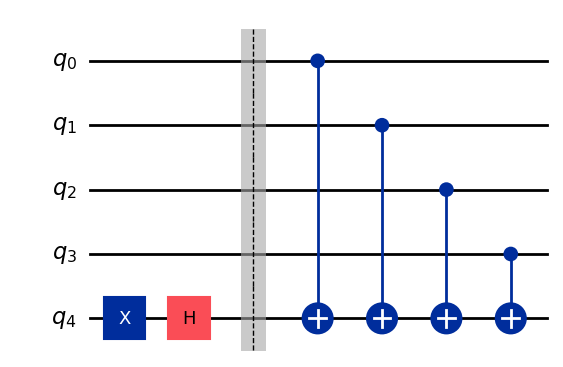

In [5]:
qc_oracle = QuantumCircuit(5)

qc_oracle.x(4)
qc_oracle.h(4)
qc_oracle.barrier()

qc_oracle.cx(0 , 4)
qc_oracle.cx(1 , 4)
qc_oracle.cx(2 , 4)
qc_oracle.cx(3 , 4)

display(qc_oracle.draw('mpl'))

**Result:** By initializing the target qubit to the $|-\rangle$ state before applying the CNOT gates, the state of the target qubit remains completely unchanged. Instead, the function's output is "kicked back" as a phase shift onto the input qubits.

### Task 2
**2. Deutsch-Jozsa Algorithm:**
* **Implement the Deutsch-Jozsa algorithm for the Boolean function from Task 1**
* **Run the algorithm and analyze the results**
* **Compare the quantum result with the classical analysis**

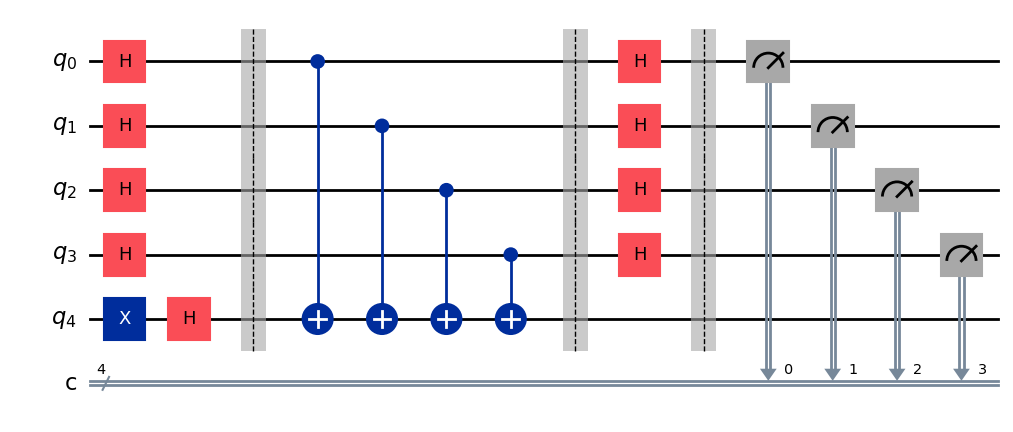

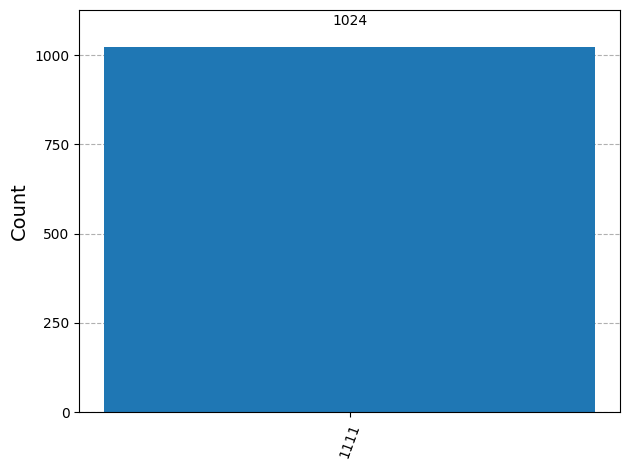

In [6]:
n = 4
qc_dj = QuantumCircuit(n+1 , n)

qc_dj.x(n)
qc_dj.h(n)

for q in range(n):
    qc_dj.h(q)
qc_dj.barrier()

for q in range(n):
    qc_dj.cx(q, n)
qc_dj.barrier()

for q in range(n):
    qc_dj.h(q)
qc_dj.barrier()

qc_dj.measure(range(n), range(n))

display(qc_dj.draw('mpl'))

result_dj = simulator.run(qc_dj).result()
plot_histogram(result_dj.get_counts())

**Result:** The measurement yields the state `1111` with 100% probability. Because the algorithm measured a state entirely different from `0000`, it proves with absolute certainty that the hidden oracle is balanced. A classical computer would have required up to $2^{n-1} + 1 = 9$ separate queries to guarantee this same conclusion, demonstrating a massive quantum speedup.

### Task 3
**3. Bernstein-Vazirani Algorithm:**
* **Implement the Bernstein-Vazirani algorithm for the secret string s = "1011"**
* **Create the corresponding oracle**
* **Run the algorithm and verify that it correctly identifies the secret string**

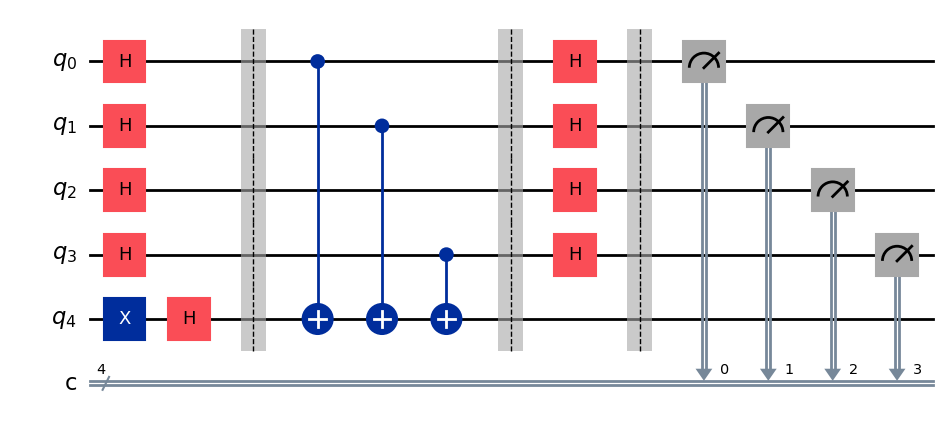

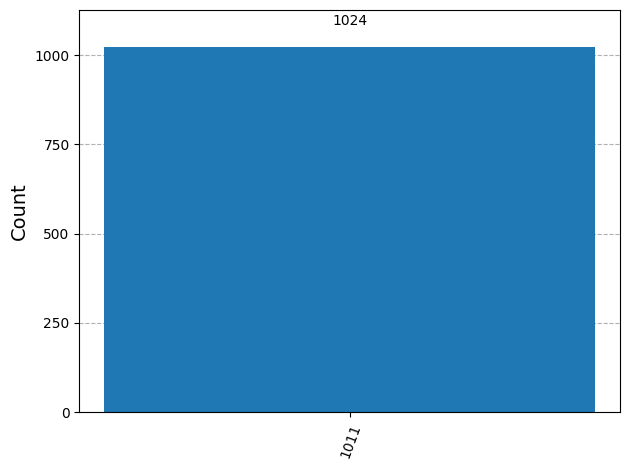

In [7]:
secret_string = '1011'
n = len(secret_string)

qc_bv = QuantumCircuit(n+1, n)

qc_bv.x(n)
qc_bv.h(n)

for q in range(n):
    qc_bv.h(q)
qc_bv.barrier()

reversed_s = secret_string[::-1] 
for q in range(n):
    if reversed_s[q] == '1':
        qc_bv.cx(q, n)
qc_bv.barrier()

for q in range(n):
    qc_bv.h(q)
qc_bv.barrier()

qc_bv.measure(range(n), range(n))

display(qc_bv.draw('mpl'))

result_bv = simulator.run(qc_bv).result()
plot_histogram(result_bv.get_counts())

**Result:** The histogram shows a 100% probability of measuring the exact state `1011`. This proves the Bernstein-Vazirani algorithm successfully extracted the entire 4-bit secret string in a single query. A classical computer would have required 4 separate queries (one for each bit) to find this same string, demonstrating a powerful linear quantum speedup.